# FSA — filtr CLIP similarity (czyste pary) + cache embeddingów

## Cel

Z par chosen/rejected zostawiamy tylko te, które są **wizualnie tą samą sceną** (inny moment, nie inna scena). Przy okazji liczymy i cache'ujemy embeddingi CLIP wszystkich obrazów — Akt 1 użyje ich gotowych.

## Logika progu similarity

- **za niskie** podobieństwo → różne sceny (odrzuć)
- **za wysokie** → niemal identyczne klatki (scena statyczna, mało sygnału momentu)
- **umiarkowane** → ta sama scena, coś się zmieniło = najbogatszy sygnał

Pokazujemy ROZKŁAD podobieństw i wybieramy próg świadomie (to też odpowiedź: ile w FSA dynamiki).

## Wejście / wyjście (Drive)
- Wejście: `fsa_pairs.csv` + `fsa_images/` (lub `pairs_manifest.csv` jeśli jest)
- Wyjście: `fsa_pairs_filtered.csv` + `clip_embeddings.npz` (cache)


## 0. Drive + CLIP

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q open_clip_torch 2>/dev/null


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import json, re
from pathlib import Path
import numpy as np
import pandas as pd
import torch, open_clip
from PIL import Image
import matplotlib.pyplot as plt

DRIVE = Path('/content/drive/MyDrive/fsa_data')
PAIRS_CSV = DRIVE / 'fsa_pairs.csv'
MANIFEST = DRIVE / 'pairs_manifest.csv'          # z notebooka pobierania (jeśli jest)
IMAGES_DIR = DRIVE / 'fsa_images'
OUT_FILTERED = DRIVE / 'fsa_pairs_filtered.csv'
EMB_CACHE = DRIVE / 'clip_embeddings.npz'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
model = model.to(device).eval()
print(f'✅ CLIP na {device}')


✅ CLIP na cuda


## 1. Wczytaj pary — odporne na brak manifestu

Preferuje `pairs_manifest.csv` (mapowanie par->pliki). Jeśli go brak, buduje mapowanie z `fsa_pairs.csv` po konwencji nazw `{loc_id}__{role}.jpg`.


In [3]:
def loc_id(id_url):
    m = re.search(r'/item/([^/]+)', str(id_url))
    return m.group(1) if m else re.sub(r'[^A-Za-z0-9]', '', str(id_url))[:20]

if MANIFEST.exists():
    print(f'Używam pairs_manifest.csv')
    pairs = pd.read_csv(MANIFEST, dtype=str, keep_default_na=False)
    # manifest ma: pair_id, chosen_locid, rejected_locid, chosen_file, rejected_file
    if 'chosen_file' not in pairs.columns:
        MANIFEST_OK = False
    else:
        MANIFEST_OK = True
else:
    MANIFEST_OK = False

if not MANIFEST_OK:
    print('Brak manifestu — buduję mapowanie z fsa_pairs.csv')
    raw = pd.read_csv(PAIRS_CSV, dtype=str, keep_default_na=False)
    raw['chosen_locid'] = raw['chosen_id'].apply(loc_id)
    raw['rejected_locid'] = raw['rejected_id'].apply(loc_id)
    raw['chosen_file'] = raw['chosen_locid'] + '__chosen.jpg'
    raw['rejected_file'] = raw['rejected_locid'] + '__rejected.jpg'
    raw['pair_id'] = [f'{i:06d}' for i in range(len(raw))]
    pairs = raw[['pair_id','chosen_locid','rejected_locid','chosen_file','rejected_file','scene','method']]

# Zostaw tylko pary, gdzie OBA pliki istnieją na Drive
def both_exist(r):
    return (IMAGES_DIR/r['chosen_file']).exists() and (IMAGES_DIR/r['rejected_file']).exists()
pairs = pairs[pairs.apply(both_exist, axis=1)].reset_index(drop=True)
print(f'Par z obydwoma obrazami na Drive: {len(pairs)}')


Używam pairs_manifest.csv
Par z obydwoma obrazami na Drive: 19739


## 2. Policz embeddingi CLIP wszystkich unikalnych obrazów (z cache)

In [4]:
# ============================================================
# 2. Embeddingi CLIP (z cache) — wersja naprawiona RAM
# ============================================================
unique_files = pd.unique(pairs[['chosen_file','rejected_file']].values.ravel())
print(f'Unikalnych obrazów: {len(unique_files)}')

# --- Wczytaj cache RAZ (nie w pętli!) ---
cached_files = []
cached_emb = None
if EMB_CACHE.exists():
    with np.load(EMB_CACHE, allow_pickle=True) as data:
        cached_files = list(data['files'])   # dekompresja RAZ
        cached_emb = data['emb']             # dekompresja RAZ -> zwykły array
    print(f'  Cache: {len(cached_files)} embeddingów wczytanych')

file_to_idx = {f: i for i, f in enumerate(cached_files)}
to_encode = [f for f in unique_files if f not in file_to_idx]
print(f'  Do policzenia: {len(to_encode)}')

# --- Dolicz brakujące (jeśli są) ---
if to_encode:
    @torch.no_grad()
    def encode(path):
        img = Image.open(path).convert('RGB')
        x = preprocess(img).unsqueeze(0).to(device)
        e = model.encode_image(x)
        e = e / e.norm(dim=-1, keepdim=True)
        return e[0].cpu().numpy().astype(np.float32)

    from tqdm.auto import tqdm
    new_embs = []
    new_files = []
    for f in tqdm(to_encode, desc='CLIP encode'):
        try:
            new_embs.append(encode(IMAGES_DIR / f))
            new_files.append(f)
        except Exception as e:
            print(f'  ⚠ {f}: {e}')

    # Połącz stare + nowe i zapisz RAZ na końcu
    if cached_emb is not None and len(cached_emb) > 0:
        all_emb = np.vstack([cached_emb, np.array(new_embs, dtype=np.float32)])
        all_files = cached_files + new_files
    else:
        all_emb = np.array(new_embs, dtype=np.float32)
        all_files = new_files
    np.savez_compressed(EMB_CACHE, files=np.array(all_files), emb=all_emb)
    print(f'✅ Zapisano cache: {len(all_files)} embeddingów')
else:
    all_emb = cached_emb
    all_files = cached_files
    print('✅ Wszystko w cache — nic do liczenia')

# Finalna struktura: JEDEN array + mapa nazwa->indeks (RAM-friendly)
file_to_idx = {f: i for i, f in enumerate(all_files)}
print(f'Embeddingi gotowe: array {all_emb.shape}, mapa {len(file_to_idx)} plików')

Unikalnych obrazów: 27891
  Cache: 27891 embeddingów wczytanych
  Do policzenia: 0
✅ Wszystko w cache — nic do liczenia
Embeddingi gotowe: array (27891, 512), mapa 27891 plików


## 3. Policz similarity chosen vs rejected w każdej parze

In [5]:
# ============================================================
# 3. Similarity chosen vs rejected — wektorowo
# ============================================================
def get_emb_idx(fname):
    return file_to_idx.get(fname, -1)

ci = pairs['chosen_file'].map(get_emb_idx).values
ri = pairs['rejected_file'].map(get_emb_idx).values
valid = (ci >= 0) & (ri >= 0)

# Wektorowe cosine: wiersz po wierszu iloczyn skalarny (embeddingi znormalizowane)
sims = np.full(len(pairs), np.nan)
sims[valid] = np.einsum('ij,ij->i', all_emb[ci[valid]], all_emb[ri[valid]])

pairs['similarity'] = sims
pairs = pairs[pairs['similarity'].notna()].reset_index(drop=True)
print(f'Similarity dla {len(pairs)} par')
print(f'  min={pairs.similarity.min():.3f}  mediana={pairs.similarity.median():.3f}  max={pairs.similarity.max():.3f}')

Similarity dla 19739 par
  min=0.306  mediana=0.803  max=0.994


## 4. Rozkład similarity — wybór progu świadomie

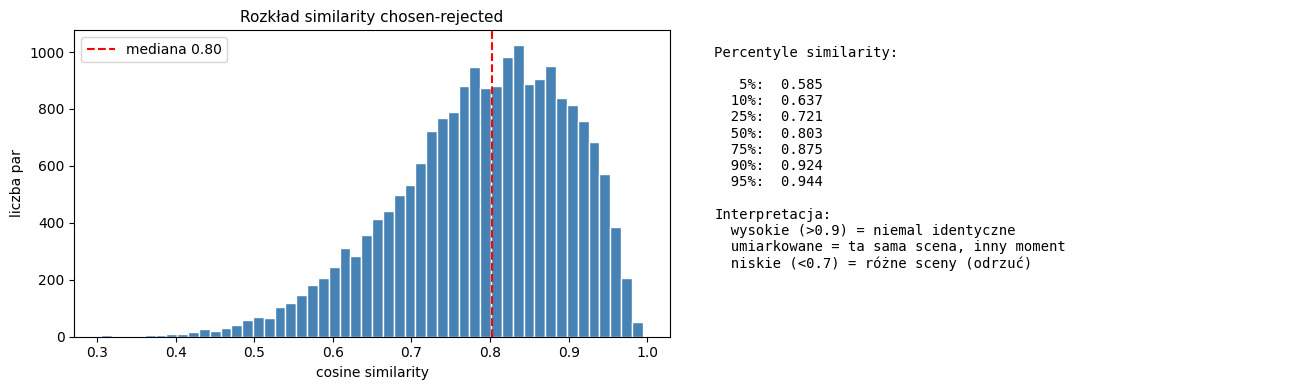

Zobacz rozkład i ustaw próg w następnej komórce.


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(pairs['similarity'], bins=50, color='steelblue', edgecolor='white')
ax[0].axvline(pairs.similarity.median(), color='red', ls='--', label=f'mediana {pairs.similarity.median():.2f}')
ax[0].set_title('Rozkład similarity chosen-rejected', fontsize=11)
ax[0].set_xlabel('cosine similarity'); ax[0].set_ylabel('liczba par'); ax[0].legend()

# Percentyle - pomocne do wyboru progu
pcts = [5,10,25,50,75,90,95]
vals = np.percentile(pairs['similarity'], pcts)
ax[1].axis('off')
txt = 'Percentyle similarity:\n\n' + '\n'.join(f'  {p:2d}%:  {v:.3f}' for p,v in zip(pcts,vals))
txt += '\n\nInterpretacja:\n  wysokie (>0.9) = niemal identyczne\n  umiarkowane = ta sama scena, inny moment\n  niskie (<0.7) = różne sceny (odrzuć)'
ax[1].text(0.05, 0.95, txt, va='top', fontfamily='monospace', fontsize=10)
plt.tight_layout(); plt.show()

print('Zobacz rozkład i ustaw próg w następnej komórce.')


## 5. Podgląd par przy różnych poziomach similarity

=== WYSOKIE similarity (~0.95) — niemal identyczne? ===


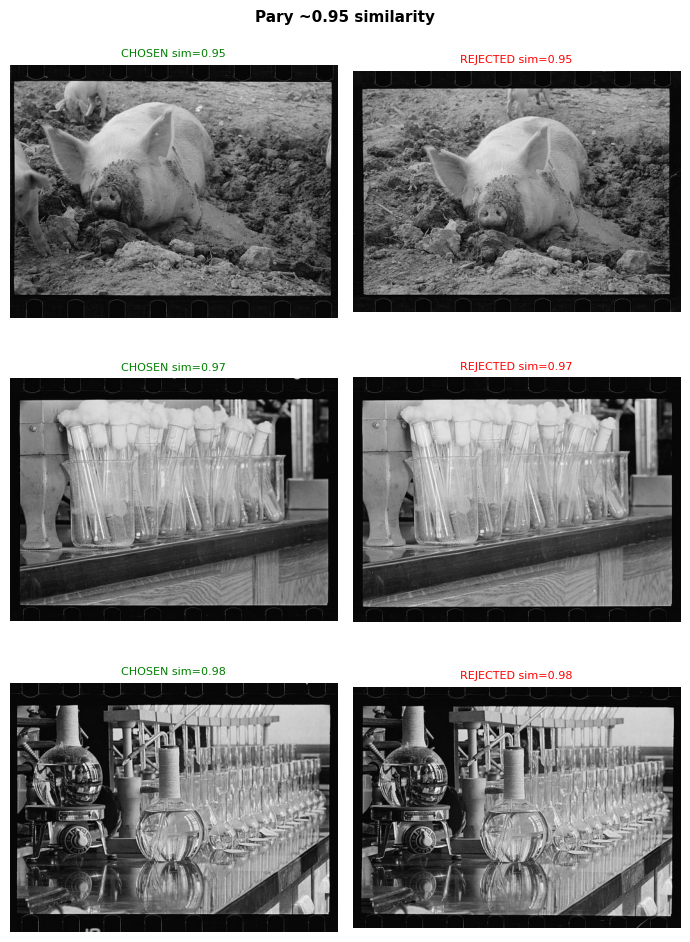

=== UMIARKOWANE (~0.80) — ta sama scena, inny moment? ===


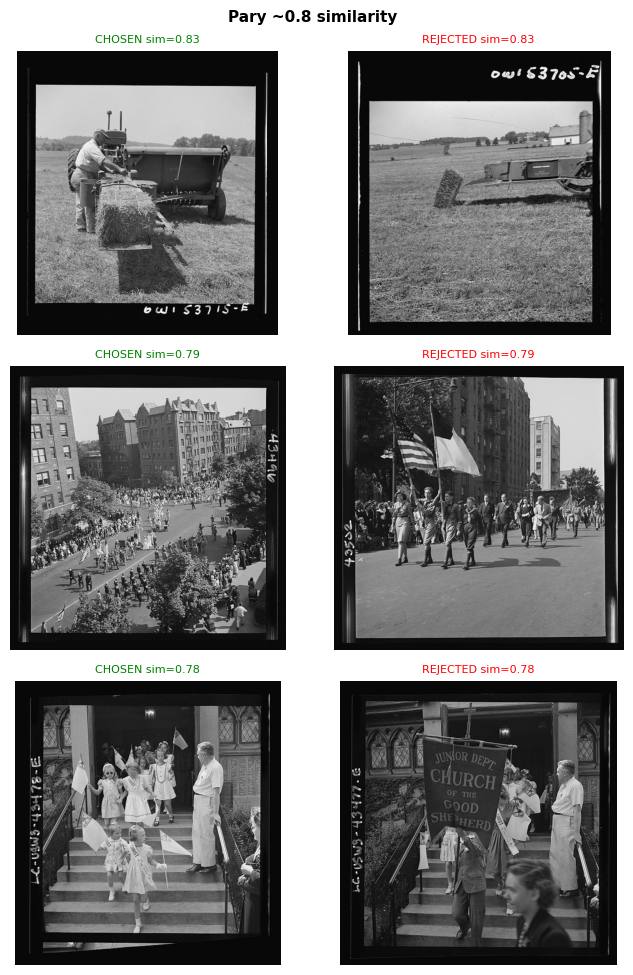

=== NISKIE (~0.60) — różne sceny? ===


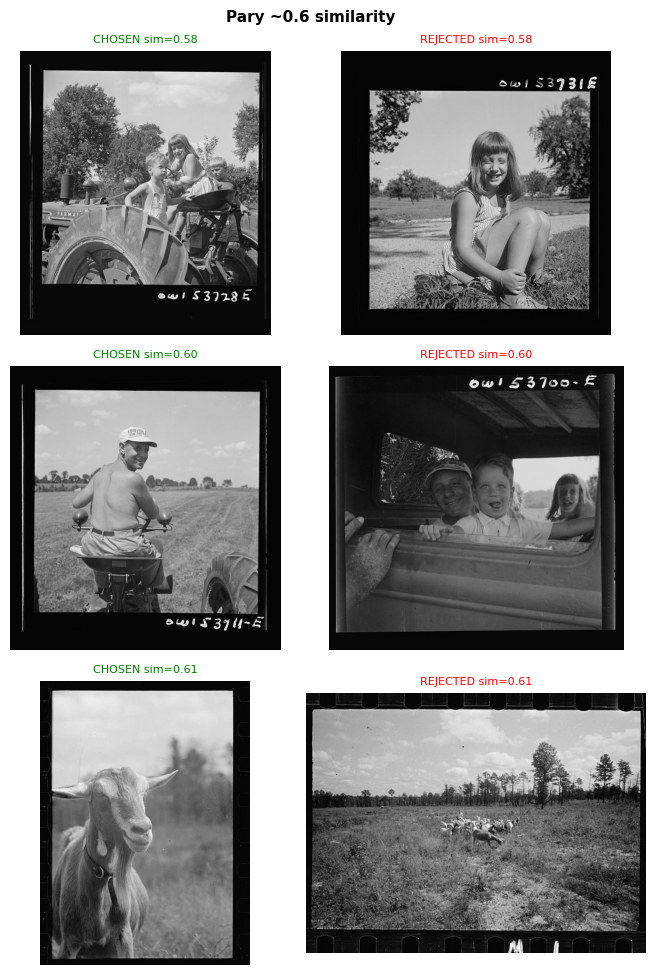

In [7]:
# Pokaż pary z różnych zakresów similarity, by zobaczyć co znaczą
def show_pairs_at(sim_target, n=3, tol=0.03):
    subset = pairs[(pairs.similarity - sim_target).abs() < tol].head(n)
    if len(subset)==0:
        print(f'Brak par ~{sim_target}'); return
    fig, axes = plt.subplots(len(subset), 2, figsize=(7, 3.3*len(subset)))
    if len(subset)==1: axes = axes.reshape(1,2)
    for i,(_,r) in enumerate(subset.iterrows()):
        for j,(f,role) in enumerate([('chosen_file','CHOSEN'),('rejected_file','REJECTED')]):
            axes[i,j].imshow(Image.open(IMAGES_DIR/r[f])); axes[i,j].axis('off')
            axes[i,j].set_title(f'{role} sim={r["similarity"]:.2f}', fontsize=8,
                                color='green' if role=='CHOSEN' else 'red')
    plt.suptitle(f'Pary ~{sim_target} similarity', fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()

print('=== WYSOKIE similarity (~0.95) — niemal identyczne? ===')
show_pairs_at(0.95)
print('=== UMIARKOWANE (~0.80) — ta sama scena, inny moment? ===')
show_pairs_at(0.80)
print('=== NISKIE (~0.60) — różne sceny? ===')
show_pairs_at(0.60)


## 6. Zastosuj próg i zapisz przefiltrowane pary

In [8]:
# Próg włączający 0.73-0.98 (wg podglądu par: <0.73 zaczynają się inne sceny)
SIM_MIN = 0.73    # odcina 'inne sceny z tego samego dnia' (koza vs stado)
SIM_MAX = 0.98    # odcina tylko duplikaty/skany, zostawia mikroruch

filtered = pairs[(pairs.similarity >= SIM_MIN) & (pairs.similarity <= SIM_MAX)].reset_index(drop=True)

# Kolumna poziomu similarity — do analizy w podgrupach w Akcie 1
def sim_level(s):
    if s >= 0.92: return 'mikroruch'      # niemal identyczne, moment ledwo się różni
    if s >= 0.82: return 'bliski'         # ta sama scena, mała różnica
    return 'wyrazny'                       # ta sama scena, wyraźnie inny moment/kompozycja
filtered['sim_level'] = filtered['similarity'].apply(sim_level)

print(f'Pary przed filtrem:  {len(pairs)}')
print(f'Pary po filtrze:     {len(filtered)}  (próg {SIM_MIN}-{SIM_MAX})')
print(f'  odrzucone różne sceny (<{SIM_MIN}):      {(pairs.similarity < SIM_MIN).sum()}')
print(f'  odrzucone duplikaty (>{SIM_MAX}):        {(pairs.similarity > SIM_MAX).sum()}')
print()
print('Rozkład poziomów similarity (gdzie mieszka moment):')
for lvl in ['wyrazny','bliski','mikroruch']:
    n = (filtered['sim_level']==lvl).sum()
    print(f'  {lvl:10}: {n:5d} par ({n*100//max(len(filtered),1)}%)')

filtered.to_csv(OUT_FILTERED, index=False)
print(f'\n✅ Zapisano: {OUT_FILTERED.name} ({len(filtered)} czystych par, z kolumną sim_level)')
print(f'   Embeddingi w cache: {EMB_CACHE.name}')
print(f'\nNastępny krok: Akt 1 — oś decydującego momentu (z neutralizacją konfoundów)')


Pary przed filtrem:  19739
Pary po filtrze:     14266  (próg 0.73-0.98)
  odrzucone różne sceny (<0.73):      5410
  odrzucone duplikaty (>0.98):        63

Rozkład poziomów similarity (gdzie mieszka moment):
  wyrazny   :  5585 par (39%)
  bliski    :  6567 par (46%)
  mikroruch :  2114 par (14%)

✅ Zapisano: fsa_pairs_filtered.csv (14266 czystych par, z kolumną sim_level)
   Embeddingi w cache: clip_embeddings.npz

Następny krok: Akt 1 — oś decydującego momentu (z neutralizacją konfoundów)


## 7. Co dalej — Akt 1

Masz teraz:
- `fsa_pairs_filtered.csv` — czyste pary (ta sama scena, inny moment)
- `clip_embeddings.npz` — embeddingi CLIP wszystkich obrazów (Akt 1 użyje gotowych)

Akt 1 policzy oś decydującego momentu PRZED i PO neutralizacji konfoundów (dziurka, ostrość) i sprawdzi, czy separacja przetrwała. To werdykt: prawdziwy sygnał czy artefakt.

### Uwaga o progu
Jeśli po podglądzie (komórka 5) widzisz, że nawet ~0.6 to ta sama scena, obniż SIM_MIN. FSA ma sceny statyczne, więc similarity bywa wysokie — nie bój się przesunąć progów wg tego, co realnie widać na obrazach.
